In [9]:
import pandas as pd

nsmes1988_df = pd.read_csv("NSMES1988-NSMES1988.csv")

nsmes1988_df

nsmes1988_df.info(verbose=True, show_counts=True)
nsmes1988_df.describe(include='all')
na_rows = nsmes1988_df.isna().any(axis=1)
nsmes1988_df.loc[na_rows]
#print(nsmes1988_df.value_counts()[nsmes1988_df.value_counts().dtype == 'object'])

nsmes1988_df.to_json("nsmes1988.json")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  4406 non-null   int64  
 1   visits      4406 non-null   int64  
 2   nvisits     4406 non-null   int64  
 3   ovisits     4406 non-null   int64  
 4   novisits    4406 non-null   int64  
 5   emergency   4406 non-null   int64  
 6   hospital    4406 non-null   int64  
 7   health      4406 non-null   object 
 8   chronic     4406 non-null   int64  
 9   adl         4406 non-null   object 
 10  region      4406 non-null   object 
 11  age         4406 non-null   float64
 12  gender      4406 non-null   object 
 13  married     4406 non-null   object 
 14  school      4406 non-null   int64  
 15  income      4406 non-null   float64
 16  employed    4406 non-null   object 
 17  insurance   4406 non-null   object 
 18  medicaid    4406 non-null   object 
dtypes: float64(2), int64(9), ob

# NSMES Data
####  Null Data:
        Contains no null values that I could find off the bat. The range was 0 - 4405 and each row reported 4406 non-null values.
#### Column Names:
        Many names are less descriptive than they could be. As characters in a header, it isn't too expensive to give them better names at the expense of header readability on printout.
        visits  -> num_physician_office_visits
        nvisits -> num_non_physician_office_visits
        ovisits -> num_outpatient_physician_office_visits
        novisits-> num_outpatient_non_physician_office_visits
        emergency -> num_emergency_visits
        hospital -> num_hospital_stays
        health -> self_reported_health_factor
        chronic -> num_chronic_conds
        adl -> daily_acty_limit_factor
        region -> region
        age -> age_div_10 or multiply age by 10 to get actual age
        gender -> gender
        married -> married
        school -> num_school_years
        income -> income_div_10k or multiply income by 10k to get actual income
        employed -> employed
        insurance -> has_priv_insurance
        medicaid -> has_medicaid_coverage

many dtypes could be updated and or changed to be boolean (e.g married, employed) and others could be enumerated to save on string space in larger databases. Just use a key



### Data Review
##### Modify the datatypes of your dataframe to match the datatypes from your previous comments (last week).
######    (i.e. if you though feature X should be type Y, now you should do the modifications)
##### (Assume you have verified these columns need modified) Perform the following operations on age and income columns.
######    Multiply age by 10
######    Multiply income by 10000
 

In [10]:
from unittest import result


nsmes1988_df['age'] = nsmes1988_df['age'] * 10
nsmes1988_df['income'] = nsmes1988_df['income'] * 10000
nsmes1988_df.rename(columns={"visits":"num_physician_office_visits",
                             "nvisits":"num_non_physician_office_visits",
                             "ovisits":"num_outpatient_physician_office_visits",
                             "novisits":"num_outpatient_non_physician_office_visits",
                             "emergency":"num_emergency_visits",
                             "hospital":"num_hospital_stays",
                             "health":"self_reported_health_factor",
                             "chronic":"num_chronic_conds",
                             "adl":"daily_acty_limit_factor",
                             "school":"num_school_years",
                             "insurance":"has_priv_insurance",
                             "medicaid":"has_medicaid_coverage"}, inplace=True)

print(nsmes1988_df['has_priv_insurance'].value_counts())
print(nsmes1988_df['has_medicaid_coverage'].value_counts())
print(nsmes1988_df['employed'].value_counts())


# Remap yes/no string to True/False boolean data
d = {'yes':True, 'no':False}
nsmes1988_df['married'] = nsmes1988_df['married'].map(d)
nsmes1988_df['has_priv_insurance'] = nsmes1988_df['has_priv_insurance'].map(d)
nsmes1988_df['has_medicaid_coverage'] = nsmes1988_df['has_medicaid_coverage'].map(d)
nsmes1988_df['employed'] = nsmes1988_df['employed'].map(d)
d = {'male':0, 'female':1}
nsmes1988_df['gender'] = nsmes1988_df['gender'].map(d)
# Remap most integer data as int8 as we won't be needing 64 bits of storage per unit (could maybe even go to int4 or int2)
nsmes1988_df['gender'] = nsmes1988_df['gender'].astype('Int8')
nsmes1988_df['num_school_years'] = nsmes1988_df['num_school_years'].astype('Int8')
nsmes1988_df['num_chronic_conds'] = nsmes1988_df['num_chronic_conds'].astype('Int8')
nsmes1988_df['num_physician_office_visits'] = nsmes1988_df['num_physician_office_visits'].astype('Int8')
nsmes1988_df['num_non_physician_office_visits'] = nsmes1988_df['num_non_physician_office_visits'].astype('Int8')
nsmes1988_df['num_outpatient_physician_office_visits'] = nsmes1988_df['num_outpatient_physician_office_visits'].astype('Int16')
nsmes1988_df['num_outpatient_non_physician_office_visits'] = nsmes1988_df['num_outpatient_non_physician_office_visits'].astype('Int16')

nsmes1988_df.convert_dtypes()
nsmes1988_df.info()

nsmes1988_df.describe()

nsmes1988_df.to_json("nsmes1988.json")
nsmes1988_df.to_csv("updated_nsmes1988.csv")

has_priv_insurance
yes    3421
no      985
Name: count, dtype: int64
has_medicaid_coverage
no     4004
yes     402
Name: count, dtype: int64
employed
no     3951
yes     455
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 19 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  4406 non-null   int64  
 1   num_physician_office_visits                 4406 non-null   Int8   
 2   num_non_physician_office_visits             4406 non-null   Int8   
 3   num_outpatient_physician_office_visits      4406 non-null   Int16  
 4   num_outpatient_non_physician_office_visits  4406 non-null   Int16  
 5   num_emergency_visits                        4406 non-null   int64  
 6   num_hospital_stays                          4406 non-null   int64  
 7   self_reported_health_factor                 4406 non-null   object 
 8   num_chronic_conds                           4406 non-null   Int8   
 9   daily_acty_limit_factor                     4406 non-null   object 
 10  region      

### Visualize Data
##### Create graphs with data that stands out and has potential indicators or unique qualities


NameError: name 'counter' is not defined

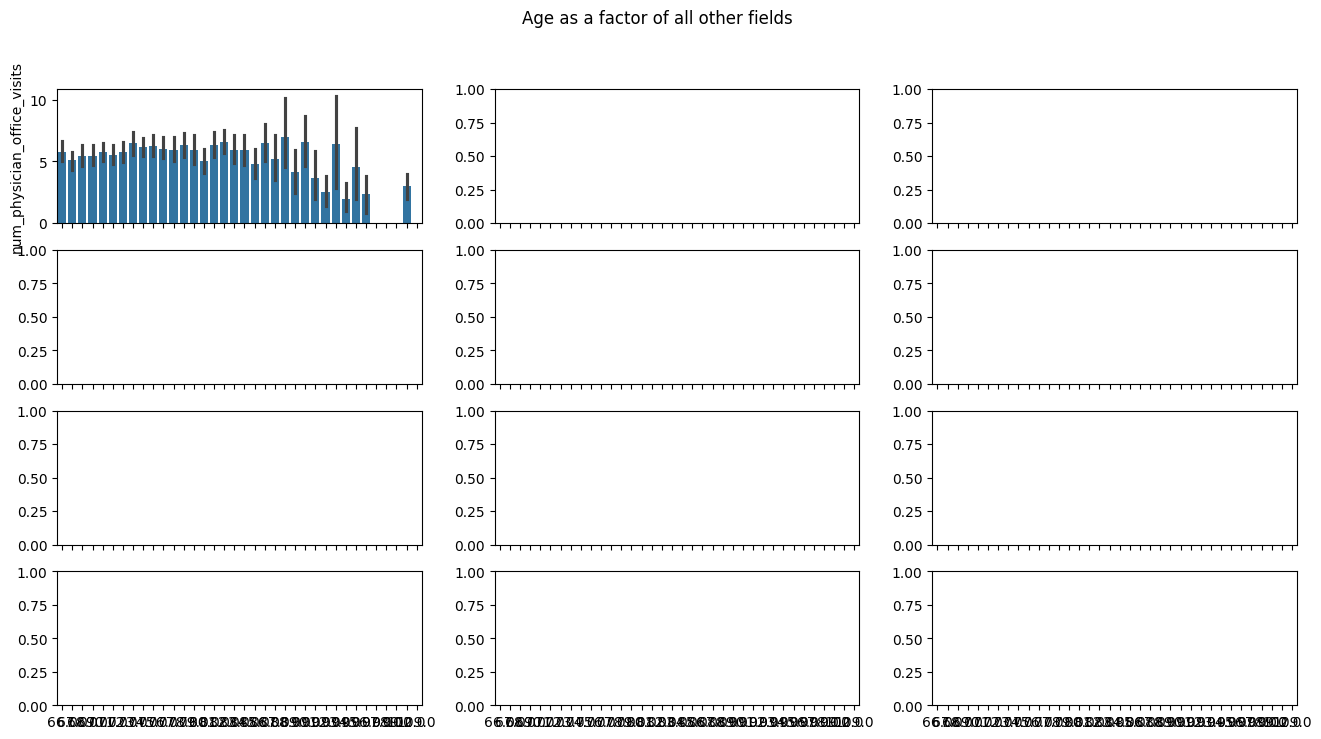

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4,3,sharex=True, figsize=(16,8))
fig.suptitle('Age as a factor of all other fields')

y_list = ['num_physician_office_visits',
            'num_non_physician_office_visits',
            'num_outpatient_physician_office_visits',
            'num_outpatient_non_physician_office_visits',
            'num_emergency_visits',
            'num_hospital_stays',
            'num_chronic_conds',
            'num_school_years',
            'income',
            'employed',
            'has_priv_insurance',
            'has_medicaid_coverage']
# age_num = nsmes1988_df.set_index('age')
counterx = 0
countery = 0
for y_c in y_list:
    sns.barplot(data=nsmes1988_df, ax=axes[counterx, countery], x='age',y=y_c)
    axes[counterx, countery].set_title=f'Age x {y_c}'
    if counterx < 2:
        counter += 1
    else:
        countery += 1
        counterx = 0

plt.plot()



### Goals
- What I was trying to do was map everything to be plotted with 'age' as the x axis as there was a significant bump in data, when the age went up.
- I was hoping to see exactly how and what ages were the most hospitalized and and which values were most affected by age all in a single graph.
- Some values were left out as tehy were not going to be useful to plot or were string data that was hard to make relevant (Like the self-reported health factor)
### End state
- I'll likely keep fiddiling with this on my own time because the data science and relationships seen in the graphs is hardest for me to get down.